# Inspect a single projector-assay DataFrame

Build the tidy per-assay df for one assay (without writing a parquet) and poke at it to
check it looks reasonable: columns, LED-block alignment, behavior fractions, dot/fly
geometry, and a few quick plots.

Run with the **flytracker** kernel.

In [1]:
import os, sys, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# put the repo root on sys.path so `analyses.projector...` imports work from anywhere
root = os.getcwd()
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'analyses', 'projector')):
    root = os.path.dirname(root)
sys.path.insert(0, root)

%load_ext autoreload
%autoreload 2
from analyses.projector.src import data_io as dio, led_metadata as lm, calibration as cal, analyze_outerdot as ao
print('repo root:', root)

repo root: /Users/juliechen/Library/CloudStorage/Dropbox-Dropbox@RU/Julie Chen/Ruta lab rotation 2026/flytracker


In [5]:
# ── CONFIG ────────────────────────────────────────────────────
assay_type_dir = '/Users/juliechen/Library/CloudStorage/Dropbox-Dropbox@RU/Julie Chen/Ruta lab rotation 2026/behavioral_data/projector-male-2dot/circle2r-25-matched-opposite_1x60s_17mm_9mm_6blocks'
assay          = '20260617-1557_Dyak3_4do_4dATR_sh'   # set None to grab the first assay below

# px->mm calibration: use the saved per-assay value if present, else a placeholder
# so you can still inspect geometry (mm columns will just be px / PLACEHOLDER).
PLACEHOLDER_PX_PER_MM = 10.0

if assay is None:
    assay = dio.list_assays(assay_type_dir)[0]
print('assay:', assay)
print('available assays:', dio.list_assays(assay_type_dir))

assay: 20260617-1557_Dyak3_4do_4dATR_sh
available assays: ['20260617-1557_Dyak3_4do_4dATR_sh', '20260617-1605_Dyak4_4do_4dATR_sh', '20260617-1614_Dyak5_4do_4dATR_sh', '20260617-1624_Dmel1_3do_1dATR_sh', '20260617-1633_Dyak6_4do_4dATR_sh', '20260617-1641_Dmel2_3do_1dATR_sh', '20260617-1648_Dmel3_3do_1dATR_sh', '20260617-1659_Dmel4_3do_1dATR_sh', '20260617-1712_Dmel5_3do_1dATR_sh', '20260618-1123_Dyak1_4do_4dATR_sh', '20260618-1136_Dyak2_4do_4dATR_sh', '20260618-1152_Dyak3_4do_4dATR_sh', '20260618-1200_Dyak4_4do_4dATR_sh', '20260618-1207_Dyak5_4do_4dATR_sh', '20260618-1217_Dyak6_3do_3dATR_sh', '20260618-1227_Dmel1_3do_1dATR_sh', '20260618-1243_Dmel2_3do_1dATR_sh', '20260618-1748_Dmel3_3do_1dATR_sh', '20260618-1759_Dmel4_3do_1dATR_sh', '20260618-1808_Dmel5_3do_1dATR_sh', '20260619-1613_Dyak1_4do_4dATR_sh', '20260619-1621_Dyak2_4do_4dATR_sh', '20260619-1629_Dyak3_3do_3dATR_sh', '20260619-1643_Dmel1_3do_1dATR_sh', '20260619-1720_Dmel2_3do_1dATR_sh', '20260619-1733_Dmel3_3do_1dATR_sh', '2026

In [6]:
# resolve calibration (placeholder if this assay type hasn't been calibrated yet)
if cal.has_calibration(assay_type_dir):
    px_per_mm = cal.load_calibration(assay_type_dir)
    print(f'using saved calibration: px_per_mm = {px_per_mm:.4f}')
else:
    px_per_mm = PLACEHOLDER_PX_PER_MM
    print(f'NO saved calibration for this assay type → using placeholder px_per_mm = {px_per_mm} '
          f'(mm columns are not real yet; run calibrate_assay_type to fix)')

# To calibrate interactively instead (pops a cv2 window; once per assay type), uncomment:
#px_per_mm = cal.calibrate_assay_type(assay_type_dir, assay)

using saved calibration: px_per_mm = 19.4331


In [8]:
df = dio.build_assay_df(assay_type_dir, assay, px_per_mm=px_per_mm)
print('shape:', df.shape)
df.head()

shape: (21342, 61)


,frame,time_sec,fly_x,fly_y,fly_theta,fly_a,fly_b,fly_x_mm,fly_y_mm,fly_a_mm,...,singing_score,led_intensity,led_block,assay,assay_type,species,age_days,atr_days,fps,px_per_mm
0,0,0.00000,235.219727,621.480896,-1.858432,8.719336,2.906445,12.104076,31.980531,0.448685,...,-10.539335,NaN,-1,20260617-1557_Dyak3_4do_4dATR_sh,circle2r-25-matched-opposite_1x60s_17mm_9mm_6b...,Dyak,4,4,59.0,19.433101
1,1,0.01695,235.143005,621.494873,-1.844013,8.708980,2.902993,12.100128,31.981250,0.448152,...,-9.803826,0.0,0,20260617-1557_Dyak3_4do_4dATR_sh,circle2r-25-matched-opposite_1x60s_17mm_9mm_6b...,Dyak,4,4,59.0,19.433101
2,2,0.03390,235.055389,621.401367,-1.842694,8.730872,2.910291,12.095619,31.976438,0.449278,...,-9.405299,0.0,0,20260617-1557_Dyak3_4do_4dATR_sh,circle2r-25-matched-opposite_1x60s_17mm_9mm_6b...,Dyak,4,4,59.0,19.433101
3,3,0.05085,234.977570,621.309570,-1.844324,8.723352,2.907784,12.091614,31.971715,0.448891,...,-9.353399,0.0,0,20260617-1557_Dyak3_4do_4dATR_sh,circle2r-25-matched-opposite_1x60s_17mm_9mm_6b...,Dyak,4,4,59.0,19.433101
4,4,0.06780,235.043411,621.536194,-1.843015,8.689057,2.896352,12.095003,31.983376,0.447127,...,-9.481527,0.0,0,20260617-1557_Dyak3_4do_4dATR_sh,circle2r-25-matched-opposite_1x60s_17mm_9mm_6b...,Dyak,4,4,59.0,19.433101


## Columns, dtypes, and baked metadata

In [9]:
print('columns:')
for c in df.columns:
    print(f'  {c:<24} {df[c].dtype}')

meta_cols = ['assay', 'assay_type', 'species', 'age_days', 'atr_days', 'fps', 'px_per_mm']
print('\nbaked metadata (constant per assay):')
print(df[meta_cols].iloc[0])

columns:
  frame                    int64
  time_sec                 float64
  fly_x                    float64
  fly_y                    float64
  fly_theta                float64
  fly_a                    float64
  fly_b                    float64
  fly_x_mm                 float64
  fly_y_mm                 float64
  fly_a_mm                 float64
  fly_b_mm                 float64
  innerdot_x               float64
  innerdot_x_mm            float64
  innerdot_y               float64
  innerdot_y_mm            float64
  outerdot_x               float64
  outerdot_x_mm            float64
  outerdot_y               float64
  outerdot_y_mm            float64
  absangle_to_innerdot     float64
  absangle_to_outerdot     float64
  ang_vel                  float64
  angle_to_innerdot        float64
  angle_to_outerdot        float64
  body_length              float64
  body_length_mm           float64
  closingspeed_innerdot    float64
  closingspeed_outerdot    float64
  dangle_to_i

In [10]:
# numeric summary + any all-NaN / suspicious columns
display(df.describe().T)
na = df.isna().sum()
print('columns with NaNs:')
print(na[na > 0])

,count,mean,std,min,25%,50%,75%,max
frame,21342.0,10670.500000,6.161049e+03,0.000000,5335.250000,10670.500000,16005.750000,21341.000000
time_sec,21342.0,180.864407,1.044295e+02,0.000000,90.432203,180.864407,271.296610,361.728814
fly_x,21342.0,347.862124,1.961412e+02,57.532715,160.313549,332.414978,503.092247,745.967834
fly_y,21342.0,453.365758,1.832205e+02,57.663834,320.900688,472.190399,610.317734,743.173279
fly_theta,21342.0,-0.119277,1.965125e+00,-3.141519,-1.849956,-0.171942,1.678066,3.141564
fly_a,21342.0,8.528254,6.676982e-01,0.117799,8.218783,8.613144,8.965927,11.302131
fly_b,21342.0,2.842751,2.225661e-01,0.039266,2.739594,2.871048,2.988642,3.767377
fly_x_mm,21342.0,17.900494,1.009315e+01,2.960552,8.249509,17.105606,25.888418,38.386453
fly_y_mm,21342.0,23.329563,9.428268e+00,2.967300,16.513097,24.298252,31.406090,38.242649
fly_a_mm,21342.0,0.438852,3.435881e-02,0.006062,0.422927,0.443220,0.461374,0.581592


columns with NaNs:
led_intensity    1
dtype: int64


## LED block alignment

Each block should hold ~`fps * block_duration` frames. The JSON block schedule and the
per-frame intensity should agree, and only the pre-trigger frame(s) should be NaN.

In [11]:
json_path = lm.find_run_json(assay_type_dir, assay)
run = lm.parse_run_json(json_path)
print('run json:', os.path.basename(json_path))
print('blocks (start_sec, intensity%):', lm.led_blocks(run))
print('\nframes per LED intensity:')
print(df['led_intensity'].value_counts(dropna=False).sort_index())
print('\nframes per LED block index:')
print(df['led_block'].value_counts(dropna=False).sort_index())

run json: run_2026-06-17_15-58-09_20260617-1557_Dyak3_4do_4dATR_sh.json
blocks (start_sec, intensity%): [(0.03, 0.0), (60.025, 10.0), (120.025, 20.0), (180.025, 30.0), (240.025, 40.0), (300.025, 50.0)]

frames per LED intensity:
led_intensity
0.0     3539
10.0    3540
20.0    3540
30.0    3540
40.0    3540
50.0    3642
NaN        1
Name: count, dtype: int64

frames per LED block index:
led_block
-1       1
 0    3539
 1    3540
 2    3540
 3    3540
 4    3540
 5    3642
Name: count, dtype: int64


## Behavior scores

Fraction of frames each JAABA classifier fires, overall and per LED intensity.

In [12]:
behavior_cols = [c for c in ['chasing_outerdot', 'orienting_outerdot', 'singing'] if c in df.columns]
print('overall fraction of frames:')
print(df[behavior_cols].mean())

print('\nfraction by LED intensity:')
display(df.groupby('led_intensity')[behavior_cols].mean())

overall fraction of frames:
chasing_outerdot    0.099100
singing             0.024693
dtype: float64

fraction by LED intensity:


,chasing_outerdot,singing
led_intensity,,
0.0,0.005369,0.005086
10.0,0.002260,0.005367
20.0,0.052260,0.051977
30.0,0.060452,0.016667
40.0,0.303390,0.015254
50.0,0.168863,0.052993


## Quick visual checks

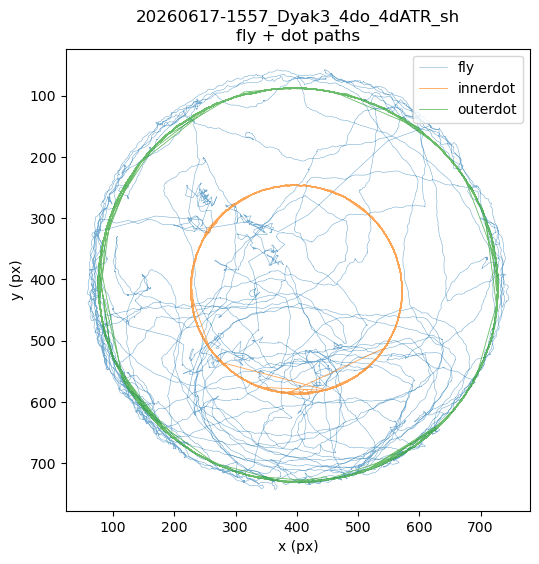

In [13]:
# fly trajectory + dot paths (image coords: y flipped so it reads like the video)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(df['fly_x'], df['fly_y'], lw=0.4, alpha=0.6, label='fly')
for dot, color in [('innerdot', 'tab:orange'), ('outerdot', 'tab:green')]:
    if f'{dot}_x' in df.columns:
        ax.plot(df[f'{dot}_x'], df[f'{dot}_y'], lw=0.6, alpha=0.7, color=color, label=dot)
ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)'); ax.legend()
ax.set_title(f'{assay}\nfly + dot paths')
plt.show()

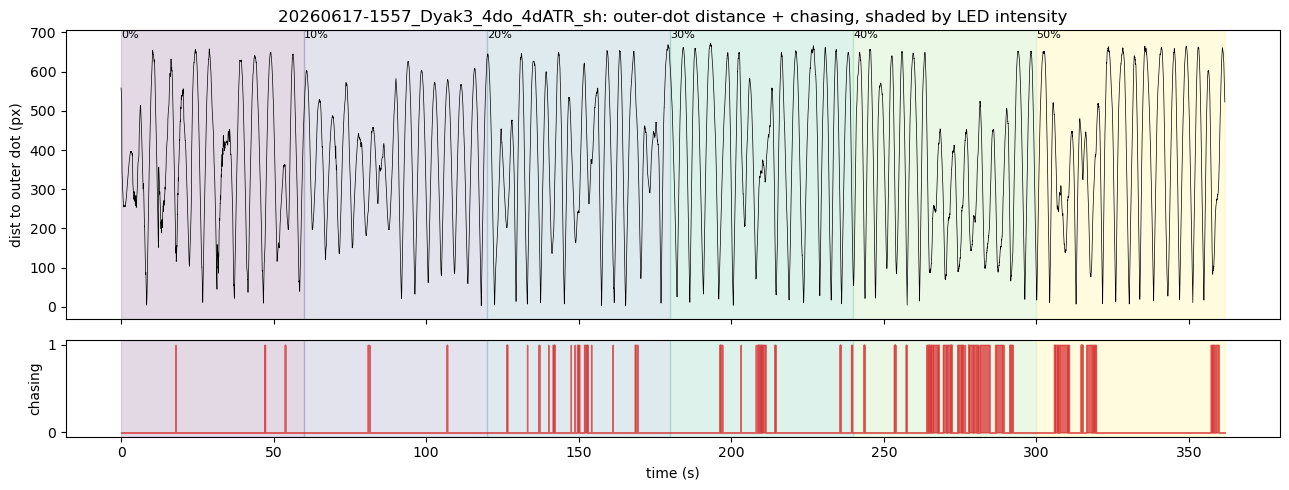

In [14]:
# distance to outer dot over time, shaded by LED block, with chasing bouts marked
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
t = df['time_sec']
ax1.plot(t, df['dist_to_outerdot'], lw=0.5, color='k')
ax1.set_ylabel('dist to outer dot (px)')

# shade LED blocks and label intensity
cmap = plt.get_cmap('viridis')
blocks = lm.led_blocks(run)
imax = max((b[1] for b in blocks), default=1) or 1
for bi, g in df.groupby('led_block'):
    if bi < 0:
        continue
    inten = g['led_intensity'].iloc[0]
    for ax in (ax1, ax2):
        ax.axvspan(g['time_sec'].iloc[0], g['time_sec'].iloc[-1],
                   color=cmap(inten / imax), alpha=0.15)
    ax1.text(g['time_sec'].iloc[0], ax1.get_ylim()[1], f'{inten:g}%',
             va='top', ha='left', fontsize=8)

# chasing raster
if 'chasing_outerdot' in df.columns:
    ax2.fill_between(t, 0, df['chasing_outerdot'], step='mid', color='tab:red', alpha=0.7)
ax2.set_yticks([0, 1]); ax2.set_ylabel('chasing'); ax2.set_xlabel('time (s)')
ax1.set_title(f'{assay}: outer-dot distance + chasing, shaded by LED intensity')
plt.tight_layout(); plt.show()

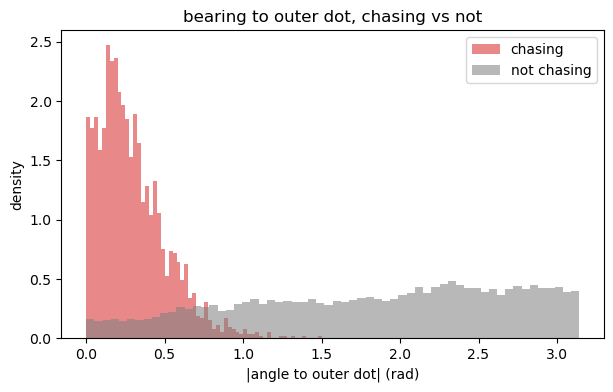

In [15]:
# sanity: angle_to_outerdot should cluster near 0 when chasing (dot dead ahead)
if {'absangle_to_outerdot', 'chasing_outerdot'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(7, 4))
    for val, label, color in [(1, 'chasing', 'tab:red'), (0, 'not chasing', 'tab:gray')]:
        sub = df[df['chasing_outerdot'] == val]['absangle_to_outerdot']
        ax.hist(sub, bins=60, density=True, alpha=0.55, label=label, color=color)
    ax.set_xlabel('|angle to outer dot| (rad)'); ax.set_ylabel('density'); ax.legend()
    ax.set_title('bearing to outer dot, chasing vs not')
    plt.show()

## Sample frames + full metric dump

Overlay the tracked fly (thorax, heading, wing tips) and dot positions on a few real video
frames, and print every computed metric/score for those frames so the geometry can be
checked against what's actually happening in the video.

In [16]:
# pick which frames to inspect. Default: a couple of chasing + a couple of non-chasing
# frames (spread out) so you see the overlay in both regimes. Override with explicit ints.
SAMPLE_FRAMES = None          # e.g. [5000, 18500, 30000]
N_PER_CLASS   = 2             # used only when SAMPLE_FRAMES is None
ZOOM_PAD_PX   = 140           # crop margin around fly+outer dot; None = full frame

def _auto_frames(df, n=2):
    valid = df[df['led_intensity'].notna()]
    out = []
    if 'chasing_outerdot' in df.columns:
        for cls in (1, 0):
            idx = valid.index[valid['chasing_outerdot'] == cls]
            if len(idx):
                out += list(idx[:: max(1, len(idx) // n)][:n])
    return sorted(set(out)) or list(valid.index[:: max(1, len(valid) // (2 * n))][:2 * n])

sample_frames = SAMPLE_FRAMES if SAMPLE_FRAMES is not None else _auto_frames(df, N_PER_CLASS)
print('sample frames:', sample_frames)

sample frames: [1, 1052, 9806, 16510]


video: 20260617-1557_Dyak3_4do_4dATR_sh_2026-06-17-155832-0000.avi
saved /Users/juliechen/Library/CloudStorage/Dropbox-Dropbox@RU/Julie Chen/Ruta lab rotation 2026/behavioral_data/projector-male-2dot/circle2r-25-matched-opposite_1x60s_17mm_9mm_6blocks/figures/20260617-1557_Dyak3_4do_4dATR_sh/frame_000001_chase0.png


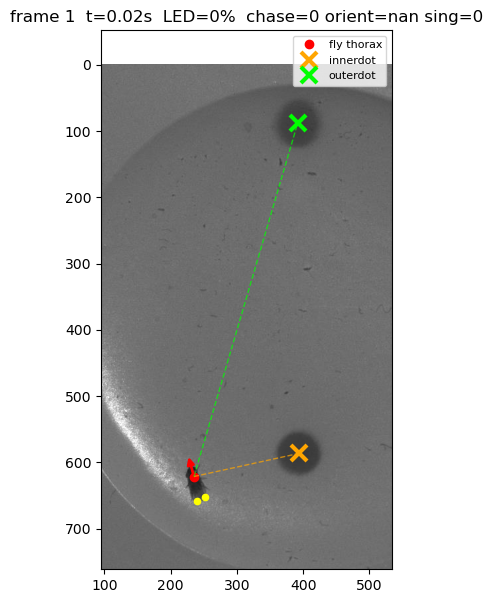

=== frame 1 — all metrics ===
-- fly pose --
fly_x            235.143
fly_y            621.495
fly_theta         -1.844
fly_a              8.709
fly_b              2.903
body_length       34.836
body_length_mm     1.793

-- fly motion --
lin_speed   0.078
ang_vel     0.014

-- wings --
wing_anglel        3.008
wing_angler        3.355
wing_angle_max     3.008
wing_angle_min     2.928
interwing_dist    12.824
xwingl           240.398
ywingl           658.838
xwingr           251.764
ywingr           652.901

-- outer dot --
outerdot_x              391.675
outerdot_y               87.957
dist_to_outerdot        556.026
dist_to_outerdot_mm      28.612
angle_to_outerdot         0.559
absangle_to_outerdot      0.559
relheading_outerdot      -0.310
closingspeed_outerdot   143.441
dangle_to_outerdot       -1.827

-- inner dot --
innerdot_x              394.075
innerdot_y              586.508
dist_to_innerdot        162.738
dist_to_innerdot_mm       8.374
angle_to_innerdot         1.627
absang

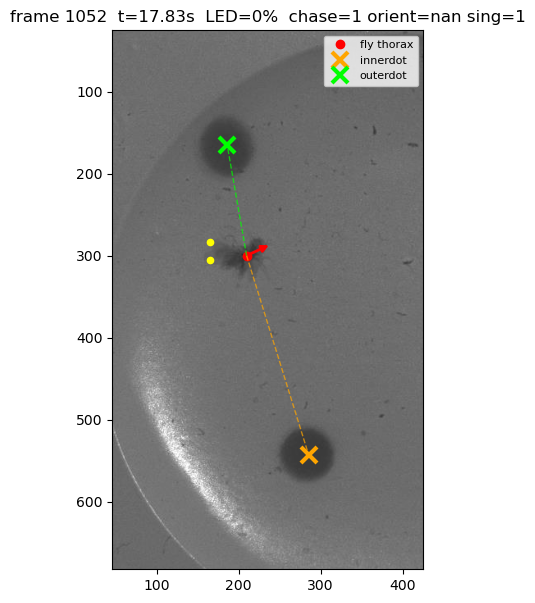

=== frame 1052 — all metrics ===
-- fly pose --
fly_x            209.717
fly_y            299.872
fly_theta         -0.435
fly_a              8.367
fly_b              2.789
body_length       33.468
body_length_mm     1.722

-- fly motion --
lin_speed   39.809
ang_vel     -0.754

-- wings --
wing_anglel        2.341
wing_angler        2.827
wing_angle_max     2.827
wing_angle_min     2.341
interwing_dist    22.483
xwingl           164.951
ywingl           282.741
xwingr           165.579
ywingr           305.215

-- outer dot --
outerdot_x              186.075
outerdot_y              164.993
dist_to_outerdot        136.935
dist_to_outerdot_mm       7.046
angle_to_outerdot        -1.309
absangle_to_outerdot      1.309
relheading_outerdot       1.116
closingspeed_outerdot    42.995
dangle_to_outerdot       24.910

-- inner dot --
innerdot_x               285.278
innerdot_y               542.498
dist_to_innerdot         254.120
dist_to_innerdot_mm       13.077
angle_to_innerdot          1.

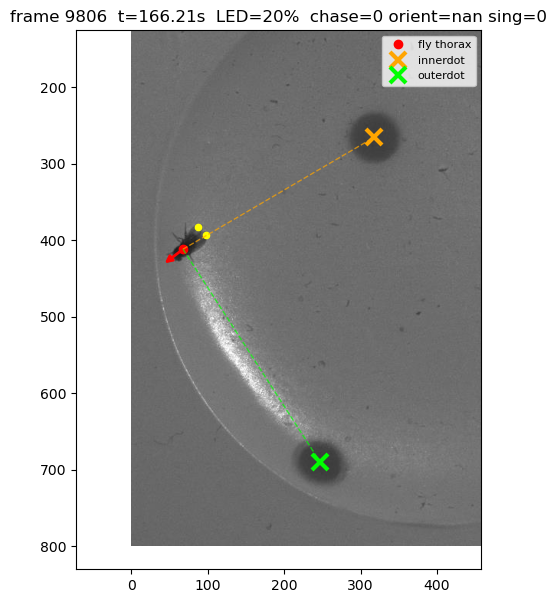

=== frame 9806 — all metrics ===
-- fly pose --
fly_x             67.822
fly_y            412.007
fly_theta          2.486
fly_a              8.440
fly_b              2.813
body_length       33.762
body_length_mm     1.737

-- fly motion --
lin_speed   0.058
ang_vel     0.007

-- wings --
wing_anglel        3.016
wing_angler        3.475
wing_angle_max     3.016
wing_angle_min     2.808
interwing_dist    15.988
xwingl            98.405
ywingl           394.054
xwingr            86.938
ywingr           382.913

-- outer dot --
outerdot_x               247.230
outerdot_y               690.349
dist_to_outerdot         331.152
dist_to_outerdot_mm       17.041
angle_to_outerdot         -1.487
absangle_to_outerdot       1.487
relheading_outerdot       -2.206
closingspeed_outerdot   -462.994
dangle_to_outerdot        -1.276

-- inner dot --
innerdot_x               317.543
innerdot_y               265.855
dist_to_innerdot         289.345
dist_to_innerdot_mm       14.889
angle_to_innerdot     

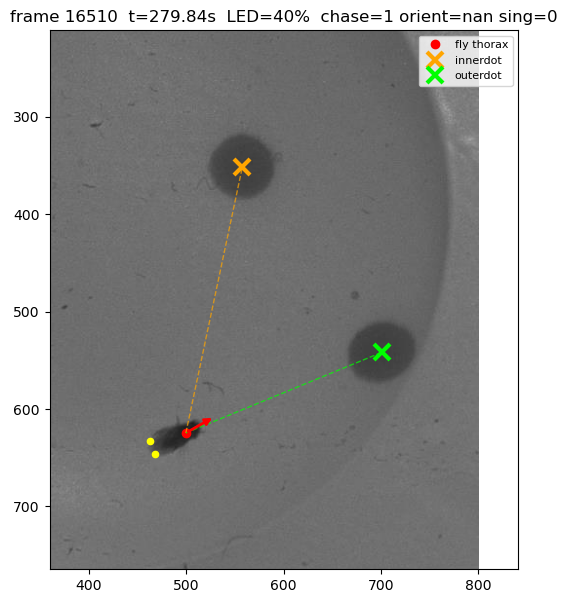

=== frame 16510 — all metrics ===
-- fly pose --
fly_x            499.624
fly_y            624.656
fly_theta         -0.518
fly_a              8.548
fly_b              2.849
body_length       34.192
body_length_mm     1.759

-- fly motion --
lin_speed   5.691
ang_vel     0.081

-- wings --
wing_anglel        2.842
wing_angler        3.210
wing_angle_max     3.073
wing_angle_min     2.842
interwing_dist    13.896
xwingl           463.277
ywingl           632.731
xwingr           467.645
ywingr           645.923

-- outer dot --
outerdot_x              700.857
outerdot_y              541.857
dist_to_outerdot        217.601
dist_to_outerdot_mm      11.197
angle_to_outerdot         0.128
absangle_to_outerdot      0.128
relheading_outerdot       1.090
closingspeed_outerdot     8.441
dangle_to_outerdot       -5.637

-- inner dot --
innerdot_x              557.752
innerdot_y              351.065
dist_to_innerdot        279.699
dist_to_innerdot_mm      14.393
angle_to_innerdot        -0.843
ab

In [17]:
import cv2

video = cal.assay_video(assay_type_dir, assay)
cap = cv2.VideoCapture(video)
print('video:', os.path.basename(video))

SAVE_FRAMES = True   # also write each annotated figure to {assay_type}/figures/{assay}/
fig_dir = os.path.join(assay_type_dir, 'figures', assay)
if SAVE_FRAMES:
    os.makedirs(fig_dir, exist_ok=True)

# metric groups to print (only those present), so the dump reads in a sensible order
_GROUPS = {
    'fly pose':        ['fly_x', 'fly_y', 'fly_theta', 'fly_a', 'fly_b', 'body_length', 'body_length_mm'],
    'fly motion':      ['lin_speed', 'ang_vel'],
    'wings':           ['wing_anglel', 'wing_angler', 'wing_angle_max', 'wing_angle_min', 'interwing_dist',
                        'xwingl', 'ywingl', 'xwingr', 'ywingr'],
    'outer dot':       ['outerdot_x', 'outerdot_y', 'dist_to_outerdot', 'dist_to_outerdot_mm',
                        'angle_to_outerdot', 'absangle_to_outerdot', 'relheading_outerdot',
                        'closingspeed_outerdot', 'dangle_to_outerdot'],
    'inner dot':       ['innerdot_x', 'innerdot_y', 'dist_to_innerdot', 'dist_to_innerdot_mm',
                        'angle_to_innerdot', 'absangle_to_innerdot', 'relheading_innerdot',
                        'closingspeed_innerdot', 'dangle_to_innerdot'],
    'behavior scores': ['chasing_outerdot', 'chasing_outerdot_score', 'orienting_outerdot',
                        'orienting_outerdot_score', 'singing', 'singing_score'],
    'context':         ['time_sec', 'led_intensity', 'led_block'],
}

def show_frame(fr):
    row = df.loc[fr]
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fr))
    ok, bgr = cap.read()
    if not ok:
        print(f'frame {fr}: could not read'); return

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

    fx, fy, th, L = row['fly_x'], row['fly_y'], row['fly_theta'], row['body_length']
    # heading arrow (image coords: +x right, +y down, theta = atan2(dy, dx))
    ax.annotate('', xy=(fx + np.cos(th) * L, fy + np.sin(th) * L), xytext=(fx, fy),
                arrowprops=dict(arrowstyle='-|>', color='red', lw=2))
    ax.plot(fx, fy, 'o', color='red', ms=6, label='fly thorax')
    for wx, wy in [('xwingl', 'ywingl'), ('xwingr', 'ywingr')]:
        if wx in row:
            ax.plot(row[wx], row[wy], '.', color='yellow', ms=9)
    for dot, color in [('innerdot', 'orange'), ('outerdot', 'lime')]:
        if f'{dot}_x' in row:
            dx, dy = row[f'{dot}_x'], row[f'{dot}_y']
            ax.plot(dx, dy, 'x', color=color, ms=12, mew=3, label=dot)
            ax.plot([fx, dx], [fy, dy], '--', color=color, lw=1, alpha=0.7)

    if ZOOM_PAD_PX is not None:
        xs = [fx] + [row[f'{d}_x'] for d in ('innerdot', 'outerdot') if f'{d}_x' in row]
        ys = [fy] + [row[f'{d}_y'] for d in ('innerdot', 'outerdot') if f'{d}_y' in row]
        ax.set_xlim(min(xs) - ZOOM_PAD_PX, max(xs) + ZOOM_PAD_PX)
        ax.set_ylim(max(ys) + ZOOM_PAD_PX, min(ys) - ZOOM_PAD_PX)   # inverted y for image
    ax.set_title(f'frame {fr}  t={row.time_sec:.2f}s  LED={row.led_intensity:g}%  '
                 f"chase={row.get('chasing_outerdot', np.nan):g} "
                 f"orient={row.get('orienting_outerdot', np.nan):g} "
                 f"sing={row.get('singing', np.nan):g}")
    ax.legend(loc='upper right', fontsize=8)

    if SAVE_FRAMES:
        chase = int(row['chasing_outerdot']) if 'chasing_outerdot' in row and pd.notna(row['chasing_outerdot']) else 0
        path = os.path.join(fig_dir, f'frame_{int(fr):06d}_chase{chase}.png')
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'saved {path}')
    plt.show()

    # full metric dump, grouped
    print(f'=== frame {fr} — all metrics ===')
    for group, cols in _GROUPS.items():
        cols = [c for c in cols if c in df.columns]
        if cols:
            print(f'-- {group} --')
            print(row[cols].to_string(float_format=lambda v: f'{v:.3f}'))
            print()

for fr in sample_frames:
    show_frame(fr)

cap.release()

## Single-assay engagement summary

Same aggregation the cross-assay analysis uses, restricted to this one assay.

In [18]:
ao.fraction_chasing_orienting(df)

,species,led_intensity,behavior,mean,sem,n_assays
0,Dyak,0.0,chasing_outerdot,0.005369,NaN,1
1,Dyak,10.0,chasing_outerdot,0.002260,NaN,1
2,Dyak,20.0,chasing_outerdot,0.052260,NaN,1
3,Dyak,30.0,chasing_outerdot,0.060452,NaN,1
4,Dyak,40.0,chasing_outerdot,0.303390,NaN,1
5,Dyak,50.0,chasing_outerdot,0.168863,NaN,1
